# Implementation of a Deep Asset Liability Management Environment

In [23]:
import os
import sys
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from environment.config import markov_config
from environment.bond import Bond
from environment.env import DeepALMEnv
from models.utils import print_bond_universe, plot_learning_curve, plot_final_wealth
from models.source.ppo import evaluate_ppo_agent, evaluate_ppo_alm
from models.DirichletPolicy import DirichletActorCriticPolicy
from typing import Callable

In [24]:
TRAINING = True
DIRICHLET = False

In [25]:
if DIRICHLET:
    # Create logging directory
    log_dir = "tmp_log/PPO9/Dirichlet"
    os.makedirs(log_dir, exist_ok=True)
else:
    log_dir = "tmp_log/PPO9/Gaussian"
    os.makedirs(log_dir, exist_ok=True)

## Gym Wrapper for SB3 compatibility

In [26]:
# Create and display bond universe
bonds = [Bond(**cfg) for cfg in markov_config["bond_configs"]]
K = len(bonds)
print_bond_universe(bonds)

# Initialize Training Environment
env = DummyVecEnv([lambda: Monitor(
    DeepALMEnv(markov_config=markov_config, seed=9, use_dirichlet=DIRICHLET), 
    filename=os.path.join(log_dir, "monitor.csv"), 
    info_keywords=('nav',)
)])

-----------------------------------------------
| Bond Type            | Maturity (Months)    |
-----------------------------------------------
| 1M_Bill              | 1                    |
| 3M_ZeroCoupon        | 3                    |
| 6M_ZeroCoupon        | 6                    |
| 12M_6Months          | 12                   |
| 24M_6Months          | 24                   |
-----------------------------------------------


In [27]:
# Linear Schedule Helper for Learning Rate
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    """
    Linear learning rate schedule.
    :param initial_value: Initial learning rate.
    :return: schedule that computes current rate depending on remaining progress
    """
    def func(progress_remaining: float) -> float:
        # progress_remaining starts at 1.0 and goes to 0.0
        return progress_remaining * initial_value
    return func

model = PPO(
    policy=DirichletActorCriticPolicy if DIRICHLET else "MultiInputPolicy",
    env=env,

    learning_rate=0.001,
    n_steps=512,
    batch_size=128,
    n_epochs=10,
    clip_range=0.1,
    
    gamma=1.0,         # No discounting: because we care about terminal utility
    gae_lambda=0.95,
    

    use_sde=False,
    ent_coef=0.001,

    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]),
        log_std_init=-2,
    ),

    verbose=1,
    device="auto"
)


Using cpu device


In [28]:
if TRAINING:
    print("Starting PPO training...")
    model.learn(total_timesteps=600_000, log_interval=10)
    print("Training completed.")
    model.save("saved_models/ppo_alm.zip")
else:
    print("Loading pre-trained model...")
    model = PPO.load("saved_models/ppo_alm.zip")


Starting PPO training...


---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 17.5      |
|    ep_rew_mean          | -0.887    |
| time/                   |           |
|    fps                  | 124       |
|    iterations           | 10        |
|    time_elapsed         | 41        |
|    total_timesteps      | 5120      |
| train/                  |           |
|    approx_kl            | 0.4517734 |
|    clip_fraction        | 0.832     |
|    clip_range           | 0.1       |
|    entropy_loss         | 3.06      |
|    explained_variance   | -2.27     |
|    learning_rate        | 0.001     |
|    loss                 | 0.0469    |
|    n_updates            | 90        |
|    policy_gradient_loss | 0.054     |
|    std                  | 0.146     |
|    value_loss           | 0.000169  |
---------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 23.6      |


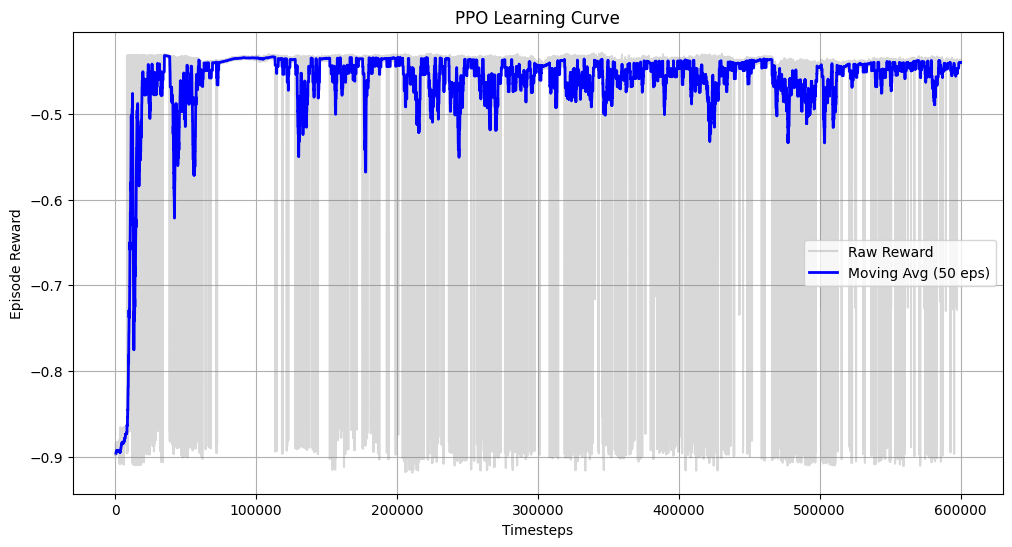

In [29]:
if TRAINING:
    plot_learning_curve(log_dir, "PPO Learning Curve")

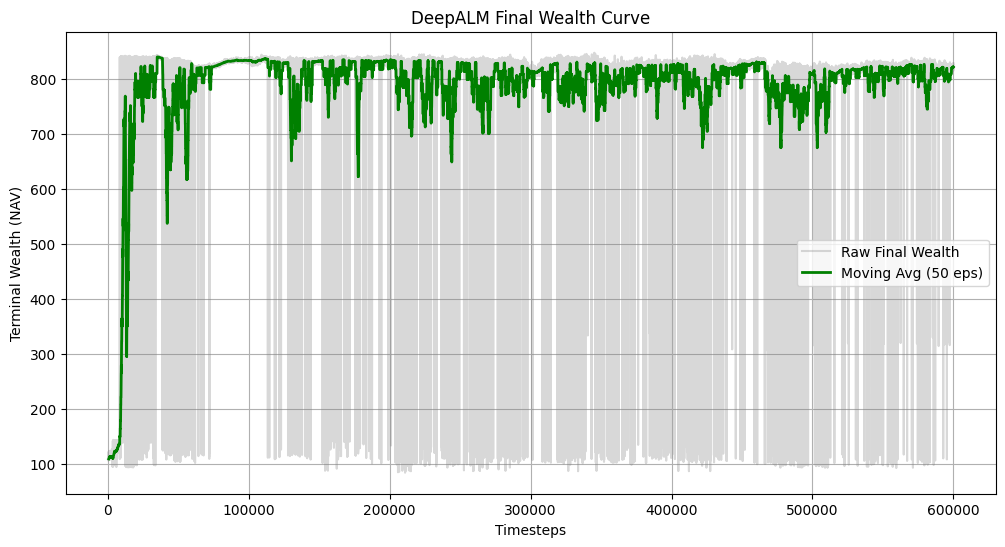

In [30]:
if TRAINING:
    plot_final_wealth(log_dir)

In [31]:
# Single-episode evaluation
print("\nRunning Single Episode Deep Dive")
evaluate_ppo_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 59.29
  Cash After Action: 994.42
  LCR: 18.8541  |  Utility: -0.47
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------

In [ ]:
# Out-of-sample statistical evaluation
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_ppo_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=2000,                
    seed_offset=10_000_000,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting PPO Evaluation ---
Ep 0 | Month  1 | NAV:   702.70 | LCR: 24.57 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   709.07 | LCR:  6.28 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   692.19 | LCR:  8.46 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   693.42 | LCR:  7.19 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   724.57 | LCR:  2.97 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   713.23 | LCR:  8.65 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   716.24 | LCR: 13.27 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   710.67 | LCR:  7.99 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   732.04 | LCR:  3.58 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   734.42 | LCR:  4.89 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   723.27 | LCR:  4.01 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   724.84 | LCR:  7.82 | Step Reward: 0.00
Ep 0 | Month 13 | NAV:   726.23 | LCR:  8.15 | Step Reward: 0.00
Ep 0 | Month 14 | NAV:   718.43 | LCR:  6.61 | Step Reward: 0.00
Ep 0 | Month 15 | NAV: 

In [ ]:
# Out-of-sample statistical evaluation
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_ppo_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=100_000,                
    seed_offset=100_000_000,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting PPO Evaluation ---
Ep 0 | Month  1 | NAV:   634.88 | LCR: 13.38 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   621.16 | LCR:  9.16 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   621.25 | LCR: 14.67 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   633.52 | LCR:  8.12 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   634.06 | LCR:  5.28 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   623.43 | LCR:  8.34 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   594.00 | LCR: 20.94 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   616.40 | LCR: 10.53 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   634.36 | LCR:  9.09 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   603.37 | LCR: 13.38 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   597.03 | LCR: 13.81 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   624.09 | LCR:  5.92 | Step Reward: 0.00
Ep 0 | Month 13 | NAV:   605.47 | LCR:  9.44 | Step Reward: 0.00
Ep 0 | Month 14 | NAV:   625.88 | LCR:  7.62 | Step Reward: 0.00
Ep 0 | Month 15 | NAV: 

Ep 0 | Month 20 | NAV:   632.19 | LCR:  7.09 | Step Reward: 0.00
Ep 0 | Month 21 | NAV:   636.04 | LCR:  4.79 | Step Reward: 0.00
Ep 0 | Month 22 | NAV:   643.91 | LCR:  3.97 | Step Reward: 0.00
Ep 0 | Month 23 | NAV:   645.60 | LCR:  4.91 | Step Reward: 0.00
Ep 0 | Month 24 | NAV:   578.96 | LCR:  6.28 | Step Reward: -0.56

=== PPO Evaluation Results ===
Mean NAV:       686.09 ± 108.27
Median NAV:     686.11
Min / Max NAV:  -369.69 / 1116.52
VaR  (5%):      508.91
CVaR (5%):      465.07
Mean Penalty:   0.0420
Violation Rate: 0.0060%
Default Rate:   0.0060%



In [34]:
print("\nRunning Single Episode Deep Dive")
evaluate_ppo_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 59.29
  Cash After Action: 828.17
  LCR: 15.6401  |  Utility: -0.47
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------